<a href="https://colab.research.google.com/github/anishdhene/Project-2-Titanic-survival/blob/main/Titanic_survival.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##**Project 2**
## **Titanic Survival Prediction**

#### Importing required libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

#### Loading the dataset

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving train.csv to train (2).csv


In [ ]:
df = pd.read_csv("train.csv")

#### Displaying the dataset

In [ ]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


#### Checking the shape of dataset

In [ ]:
df.shape

(891, 12)

#### The dataset contains 891 rows and 12 columns.

#### Understanding the **Features** of dataset

In [ ]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

##### The **Features** includes PassengerId, Survived, Pclass, Name, Sex, Age, SibSp, Parch, Ticket, Fare, Cabin, Embarked.

#### Dataset Information

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


#### Checking missing values in the dataset

In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


#### Columns like Age, Cabin, and Embarkded contains missing values.

#### Checking duplicate values in the dataset

In [ ]:
df.duplicated().sum()

np.int64(0)

#### Statistical Summary

In [ ]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### Dataset Summary


*   The dataset contains passenger information from the Titanic disaster.

*   Features include age, sex, passenger class, fare, and survival status.

*   Some columns contain missing values.

*   Both numerical and categorical features are present.


*   The dataset can be used to predict passenger survival.

####  Checking missing values of dataset for taking decisions

In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


### Decision 1: Cabin

Missing values = 687 out of 891.

In [ ]:
df.drop('Cabin', axis = 1, inplace = True)

#### The Cabin column was removed because it contained a very large number of missing values (687). Retaining this column could negatively affect model performance and data quality.

### Decision 2: Age

Missing values = 177

In [ ]:
df['Age'].fillna(df['Age'].median(), inplace = True)

/tmp/ipykernel_4517/3612560828.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace = True)


#### Missing values in the Age column were replaced using the median age. The median was chosen because it is less affected by extreme values and helps preserve the dataset size.

### Decision 3: Embarked

Missing values = 2

In [ ]:
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace = True)

/tmp/ipykernel_4517/1994620826.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Embarked'].fillna(df['Embarked'].mode()[0], inplace = True)


#### The Embarked column contained only 2 missing values. These were replaced with the most frequent embarkation port using the mode.

### Decision 4: PassengerId

This is only an identifier.

In [ ]:
df.drop('PassengerId', axis = 1, inplace = True)

#### PassengerId was removed because it serves only as a unique identifier and does not contribute meaningful information for survival prediction.

In [ ]:
df.isnull().sum()


,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0
Embarked,0


### Dataset Information



In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       891 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    object 
 8   Fare      891 non-null    float64
 9   Embarked  891 non-null    object 
dtypes: float64(2), int64(4), object(4)
memory usage: 69.7+ KB


In [ ]:
df.columns

Index(['Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket',
       'Fare', 'Embarked'],
      dtype='object')

#### Now dataset has:
* 891 rows

* 10 columns

####After Preprocessing:

Removed:

* PassengerId

* Cabin

#### Remaining Columns

* Survived

* Pclass

* Name

* Sex

* Age

* SibSp

* Parch

* Ticket

* Fare

* Embarked

## Data Preprocessing Summary

* The Cabin column was removed because it contained a large number of missing values (687 out of 891 records), which could negatively affect model performance.

* Missing values in the Age column were replaced using the median age to preserve data while reducing the impact of outliers.

* The Embarked column contained only 2 missing values, which were filled using the most frequent embarkation port (mode).

* The PassengerId column was removed because it serves only as a unique identifier and does not provide useful information for survival prediction.

* After preprocessing, the dataset contained 891 rows and 10 columns with no remaining missing values.

#### Task 1: Encode Categorical Variables

Machine Learning models cannot understand text values so we will convert them into numbers.

Checking unique values

In [ ]:
df['Sex'].unique()

array(['male', 'female'], dtype=object)

In [ ]:
df['Embarked'].unique()

array(['S', 'C', 'Q'], dtype=object)

Encoded Sex

In [ ]:
df['Sex'] = df['Sex'].map({
    'male': 0,
    'female':1
})


In [ ]:
df['Sex'].head()

,Sex
0,0
1,1
2,1
3,1
4,0


Encoded Embarked

In [ ]:
df['Embarked'] = df['Embarked'].map({
    'S':0,
    'C':1,
    'Q':2
})

In [ ]:
df['Embarked'].head()

,Embarked
0,0
1,1
2,0
3,0
4,0


Categorical variables were encoded into numerical values because machine learning algorithms cannot directly process text data.


1.   For Sex

     converted:

* male to 0
* female to 1


2.   For Embarked

     converted


*   S to 0
*   C to 1
*   Q to 2








### Task 2: Verifying Datatypes

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    int64  
 4   Age       891 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    object 
 8   Fare      891 non-null    float64
 9   Embarked  891 non-null    int64  
dtypes: float64(2), int64(6), object(2)
memory usage: 69.7+ KB


Here we can clearly see that datatypes of Sex and Embarked is int64 instead of object.

### Preparing Features and Target

Target variable is: Survived

### Task 3: Features

Since Name and Ticket are the text columns and difficult to use directlly so we will drop them for now.

In [ ]:
df = df.drop(['Name', 'Ticket'], axis = 1)

After dropping column such as Name and Ticket, checking them by using df.columns.

In [ ]:
df.columns

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked'],
      dtype='object')

### Task 4: Create x and y

Features:

In [ ]:
x = df.drop('Survived', axis = 1)

Target:

In [ ]:
y = df['Survived']

Checking x and y

In [ ]:
x.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,0,22.0,1,0,7.2500,0
1,1,1,38.0,1,0,71.2833,1
2,3,1,26.0,0,0,7.9250,0
3,1,1,35.0,1,0,53.1000,0
4,3,0,35.0,0,0,8.0500,0


In [ ]:
y.head()

,Survived
0,0
1,1
2,1
3,1
4,0


### Task 5: Train/Test Split

Import

In [ ]:
from sklearn.model_selection import train_test_split

Split

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size = 0.2,
    random_state = 42
)

Checking shapes:

In [ ]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(712, 7)
(179, 7)
(712,)
(179,)


## Encoding and Train-Test Split Summary

*  The categorical columns Sex and Embarked were converted into numerical values using label mapping so that machine learning algorithms can process them.

*  The Name and Ticket columns were removed because they contain text data that is not directly useful for basic model training.

*  The dataset was divided into features (X) and target variable (y), where Survived was selected as the prediction target.

*  The data was then split into training and testing sets using an 80:20 ratio.

*  This split allows the machine learning models to learn from one portion of the data and be evaluated on unseen data.

### Feature Engineering

#### Correlation Analysis

In [ ]:
corr = df.corr(numeric_only = True)
corr

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
Survived,1.000000,-0.338481,0.543351,-0.064910,-0.035322,0.081629,0.257307,0.106811
Pclass,-0.338481,1.000000,-0.131900,-0.339898,0.083081,0.018443,-0.549500,0.045702
Sex,0.543351,-0.131900,1.000000,-0.081163,0.114631,0.245489,0.182333,0.116569
Age,-0.064910,-0.339898,-0.081163,1.000000,-0.233296,-0.172482,0.096688,-0.009165
SibSp,-0.035322,0.083081,0.114631,-0.233296,1.000000,0.414838,0.159651,-0.059961
Parch,0.081629,0.018443,0.245489,-0.172482,0.414838,1.000000,0.216225,-0.078665
Fare,0.257307,-0.549500,0.182333,0.096688,0.159651,0.216225,1.000000,0.062142
Embarked,0.106811,0.045702,0.116569,-0.009165,-0.059961,-0.078665,0.062142,1.000000


By doing this, it will show how strongly each feature is related to other features.

#### Correlation Heatmap

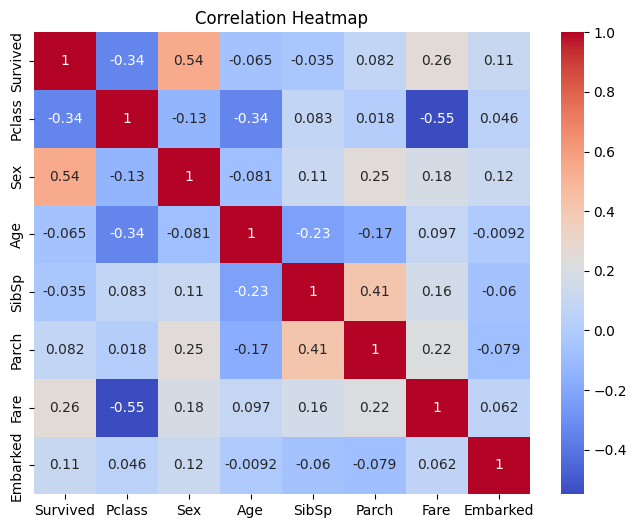

In [ ]:
plt.figure(figsize = (8, 6))
sns.heatmap(corr, annot = True, cmap = 'coolwarm')
plt.title('Correlation Heatmap')
plt.show()

*  The correlation heatmap helps visualize relationships between numerical features.

*  Values close to +1 indicate a strong positive relationship, while values close to -1 indicate a strong negative relationship.

*  Features with stronger correlation to the target variable (Survived) may have greater influence on prediction performance.

#### Correlation with Survival

In [ ]:
corr['Survived'].sort_values(ascending = False)

,Survived
Survived,1.000000
Sex,0.543351
Fare,0.257307
Embarked,0.106811
Parch,0.081629
SibSp,-0.035322
Age,-0.064910
Pclass,-0.338481


#### Analysis of Important Feature

Likely Important Features:


*   Sex
*   Pclass
*   Fare
*   Age

Moderately Important Features:
*  SibSp
*  Parch
*  Embarked

Classification of important features and moderately important features is made by:

*  The features which are strongly positive or strongly negative are considered as important features.

*  The features which are nor stongly positive or neither strongly negative are considered as moderately important features.

#### Feature Selection Decision

We will keep all the features:

*  Pclass
*  Sex
*  Age
*  SibSp
*  Parch
*  Fare
*  Embarked

Reason:
1)  Dataset is small (891 rows)
2)  Only 7 features remain
3)  None create major problems
4)  More features may improve prediction

So we won't drop any feature.

### Feature Engineering Summary

*  Correlation analysis was performed to understand the relationship between features and the target variable.

*   A correlation heatmap was created to visualize the strength and direction of relationships among numerical variables.

*  The correlation values with the Survived column were examined to identify influential features.

*  Features such as Sex, Pclass, Fare, and Age showed stronger relationships with passenger survival.

*  All remaining features were retained because the dataset contains only a small number of useful predictors and none were considered irrelevant.

#### Import Required Libraries

### Model Training

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score

Imported the required libraies for model training.

### Logistic Regression

In [ ]:
log_model = LogisticRegression(max_iter = 1000)
log_model.fit(x_train, y_train)

LogisticRegression(max_iter=1000)

#### Prediction

In [ ]:
y_pred_log = log_model.predict(x_test)

#### Accuracy

In [ ]:
log_accuracy = accuracy_score(y_test, y_pred_log)
print("Logistic Regression Accuracy:", log_accuracy)

Logistic Regression Accuracy: 0.7988826815642458


### KNN Classifier

In [ ]:
knn_model = KNeighborsClassifier(n_neighbors = 5)
knn_model.fit(x_train, y_train)

KNeighborsClassifier()

#### Prediction

In [ ]:
y_pred_knn = knn_model.predict(x_test)

#### Accuracy

In [ ]:
knn_accuracy = accuracy_score(y_test, y_pred_knn)
print("KNN Accuracy:", knn_accuracy)

KNN Accuracy: 0.6983240223463687


### Random Forest Classifier

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators = 100,
    random_state = 42
)

rf_model.fit(x_train, y_train)

RandomForestClassifier(random_state=42)

#### Prediction

In [ ]:
y_pred_rf = rf_model.predict(x_test)

#### Accuracy

In [ ]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.8268156424581006


### Comparing Accuracies

In [ ]:
print("Logistic Regression :", log_accuracy)
print("KNN :", knn_accuracy)
print("Random Forest :", rf_accuracy)

Logistic Regression : 0.7988826815642458
KNN : 0.6983240223463687
Random Forest : 0.8268156424581006


Model Training Summary

Three classification algorithms were trained on the Titanic dataset:

1. Logistic Regression
2. K-Nearest Neighbors (KNN)
3. Random Forest

*  Each model was trained using the training dataset and evaluated on the testing dataset.

*  The accuracy score was calculated for all models to compare their performance.

*  The best-performing model will be identified in the next step using additional evaluation metrics.

### Model Evaluation

In [ ]:
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

### Logistic Regression Metrics

In [ ]:
log_precision = precision_score(y_test, y_pred_log)
log_recall = recall_score(y_test, y_pred_log)
log_f1 = f1_score(y_test, y_pred_log)

print("Logistic Regression")
print("Precision :", log_precision)
print("Recall :", log_recall)
print("F1 Score :", log_f1)

Logistic Regression
Precision : 0.7714285714285715
Recall : 0.7297297297297297
F1 Score : 0.75


### KNN Metrics

In [ ]:
knn_precision = precision_score(y_test, y_pred_knn)
knn_recall = recall_score(y_test, y_pred_knn)
knn_f1 = f1_score(y_test, y_pred_knn)

print("KNN")
print("Precision :", knn_precision)
print("Recall :", knn_recall)
print("F1 Score :", knn_f1)

KNN
Precision : 0.6785714285714286
Recall : 0.5135135135135135
F1 Score : 0.5846153846153846


### Random Forest Metrics

In [ ]:
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

print("Random Forest")
print("Precision :", rf_precision)
print("Recall :", rf_recall)
print("F1 Score :", rf_f1)

Random Forest
Precision : 0.8115942028985508
Recall : 0.7567567567567568
F1 Score : 0.7832167832167832


### Creating a Comparison Table

In [ ]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN",
        "Random Forest"
    ],

    "Accuracy": [
        log_accuracy,
        knn_accuracy,
        rf_accuracy
    ],

    "Precision": [
        log_precision,
        knn_precision,
        rf_precision
    ],

    "Recall": [
        log_recall,
        knn_recall,
        rf_recall
    ],

    "F1 Score": [
        log_f1,
        knn_f1,
        rf_f1
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.798883,0.771429,0.729730,0.750000
1,KNN,0.698324,0.678571,0.513514,0.584615
2,Random Forest,0.826816,0.811594,0.756757,0.783217


#### Evaluation Summary

*  Three machine learning models were evaluated using Accuracy, Precision, Recall, and F1 Score.

*  Accuracy measures the overall correctness of predictions.

*  Precision measures how many predicted survivors were actually survivors.

*  Recall measures how many actual survivors were correctly identified.

*  F1 Score provides a balance between Precision and Recall.

The comparison table helps identify the most effective model for Titanic survival prediction.

#### Importing Required Libraries

In [ ]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

Imported the required libraries for further analysis.

Since the model Random Forest performed best, so we will use it.

### Creating Confusion Matrix for Random Forest

In [ ]:
cm = confusion_matrix(y_test, y_pred_rf)
print(cm)

[[92 13]
 [18 56]]


### Ploting Confusion Matrix

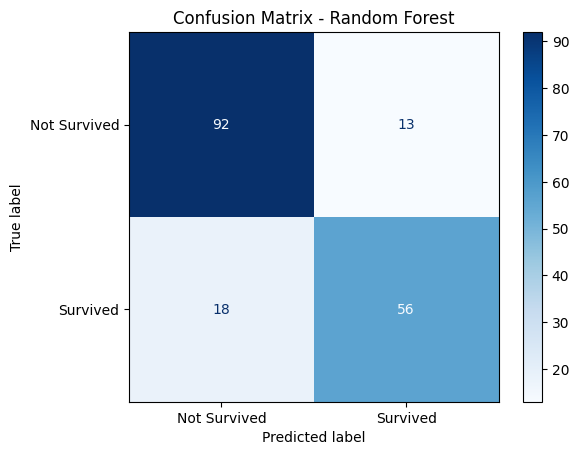

In [ ]:
disp = ConfusionMatrixDisplay(
    confusion_matrix = cm,
    display_labels = ["Not Survived", "Survived"]
)

disp.plot(cmap = 'Blues')
plt.title("Confusion Matrix - Random Forest")
plt.show()

### Best Model Analysis

Among the three models, Random Forest achieved the highest performance.

*  Accuracy = 82.68%

*  Precision = 81.16%

*  Recall = 75.68%

*  F1 Score = 78.32%

Therefore, Random Forest was selected as the best model for Titanic survival prediction.

#### Why Random Forest performed better ?

Reasons:

1. Random Forest can capture complex relationships between features.

2. It combines multiple decision trees, reducing overfitting.

3. It handled the Titanic dataset better than Logistic Regression and KNN.

4. It achieved the highest Accuracy, Precision, Recall, and F1 Score.

5. Therefore, Random Forest is the most suitable model for this problem.

### Conclusion

1. The Titanic dataset was cleaned and preprocessed successfully.

2. Three machine learning models were trained and evaluated.

3. Random Forest achieved the best performance among all models.

4. The confusion matrix showed that the model predicted survival effectively.

5. Therefore, Random Forest is the best choice for Titanic survival prediction.

Project Summary

• Dataset Used: Titanic Survival Prediction Dataset

• Total Models Trained:
1. Logistic Regression
2. K-Nearest Neighbors
3. Random Forest

• Evaluation Metrics Used:
Accuracy
Precision
Recall
F1 Score

• Best Model:
Random Forest

• Best Accuracy:
82.68%

This project demonstrates the complete machine learning workflow, including preprocessing, feature engineering, model training, evaluation, and model selection.